In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar y limpiar datos
path = 'csv/BaseINDICES-2005-2025.csv'
df = pd.read_csv(path, sep=';', encoding='utf-8')

# Filtrar por año
df = df[df['Año'] == 2024].copy()

# 1. Limpiamos las columnas de dinero y personas (borramos los puntos de miles)
cols_dinero_personas = [
    'Matrícula primer año hombres', 'Matrícula primer año mujeres', 
    'Vacantes', 'Matrícula Primer Año', 'Valor de arancel', 'Matrícula Total'
]

for col in cols_dinero_personas:
    df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Limpiamos las columnas de puntajes (NO borramos los puntos, solo cambiamos comas por puntos si las hay)
cols_puntajes = [
    'Promedio Puntaje (promedio matemáticas y lenguaje)', 
    'Promedio Puntaje NEM', 'Puntaje de corte (último seleccionado)'
]

for col in cols_puntajes:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Crear una columna para identificar Informática vs el Resto
target_carrera = 'Ingeniería Civil en Computación y/o Informática'
df['Categoria'] = df['Carrera Genérica'].apply(lambda x: 'Informática' if x == target_carrera else 'Otras Ingenierías')

# Filtrar para quedarnos solo con lo que sea "Ingeniería"
df_ing = df[df['Carrera Genérica'].str.contains('Ingeniería', case=False, na=False)].copy()

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

<Figure size 1200x600 with 0 Axes>

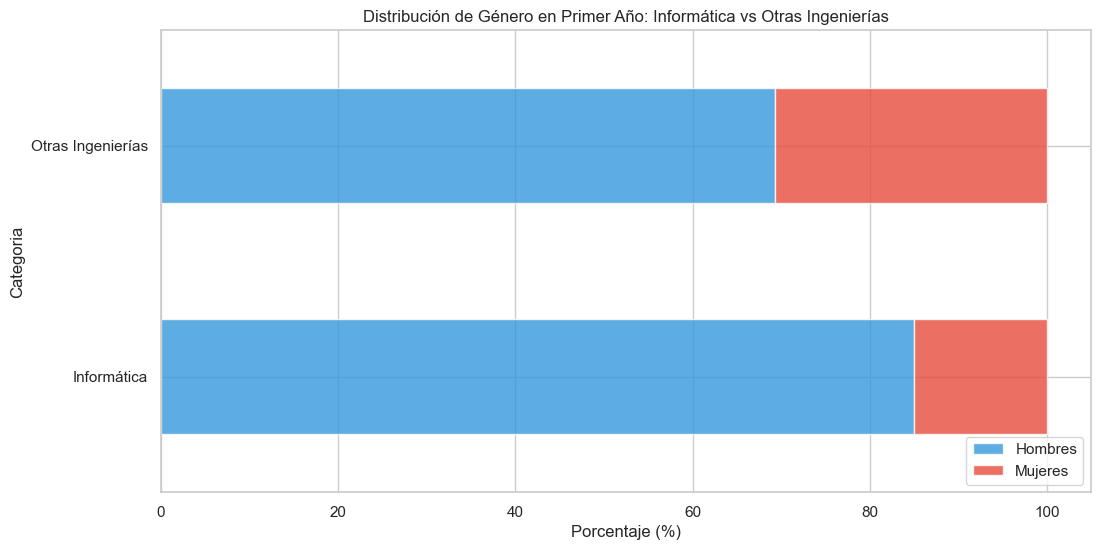

In [13]:
# --- GRÁFICO 1: BRECHA DE GÉNERO ---
plt.figure()
df_gender = df_ing.groupby('Categoria')[['Matrícula primer año hombres', 'Matrícula primer año mujeres']].sum()
df_gender_pct = df_gender.div(df_gender.sum(axis=1), axis=0) * 100

df_gender_pct.plot(kind='barh', stacked=True, color=['#3498db', '#e74c3c'], alpha=0.8)
plt.title('Distribución de Género en Primer Año: Informática vs Otras Ingenierías')
plt.xlabel('Porcentaje (%)')
plt.legend(['Hombres', 'Mujeres'], loc='lower right')
plt.savefig('brecha_genero_uach.png', dpi=300, bbox_inches='tight')
plt.show()

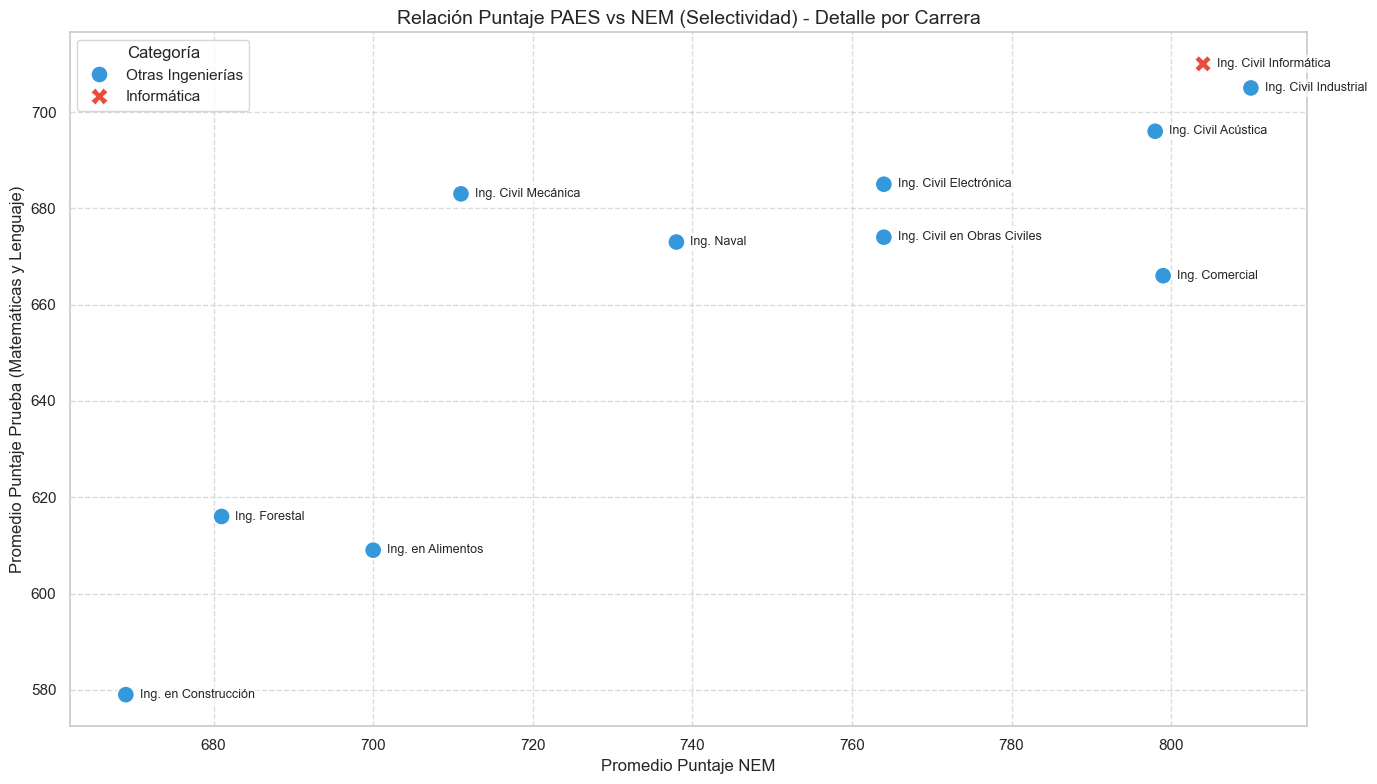

In [ ]:
# --- GRÁFICO 2: MATRIZ DE SELECTIVIDAD (NEM vs Puntaje) MEJORADO ---
plt.figure(figsize=(14, 8)) # Tamaño más grande para acomodar los textos

# Crear el gráfico de dispersión con puntos más grandes y colores más contrastantes
sns.scatterplot(
    data=df_ing, 
    x='Promedio Puntaje NEM', 
    y='Promedio Puntaje (promedio matemáticas y lenguaje)', 
    hue='Categoria', 
    style='Categoria', 
    s=150, # Puntos más grandes para mejor visibilidad
    palette={'Informática': '#e74c3c', 'Otras Ingenierías': '#3498db'}
)

# Añadir el nombre de cada carrera al lado de su punto respectivo para que se entienda
for idx, row in df_ing.iterrows():
    # Se acorta la palabra 'Ingeniería' a 'Ing.' para que el texto no sature el gráfico
    nombre_corto = str(row['Nombre Programa']).replace('Ingeniería', 'Ing.')
    
    plt.annotate(
        nombre_corto,
        (row['Promedio Puntaje NEM'], row['Promedio Puntaje (promedio matemáticas y lenguaje)']),
        xytext=(10, 0), # Desplazamiento del texto (10 puntos a la derecha)
        textcoords='offset points',
        fontsize=9,
        va='center', # Alineación vertical centrada con el punto
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2) # Fondo blanco semitransparente para legibilidad
    )

plt.title('Relación Puntaje PAES vs NEM (Selectividad) - Detalle por Carrera', fontsize=14)
plt.xlabel('Promedio Puntaje NEM', fontsize=12)
plt.ylabel('Promedio Puntaje Prueba (Matemáticas y Lenguaje)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Categoría', loc='upper left') # Mueve la leyenda si tapa algún texto
plt.tight_layout() # Ajusta los márgenes automáticamente
plt.savefig('matriz_selectividad_uach.png', dpi=300, bbox_inches='tight')
plt.show()

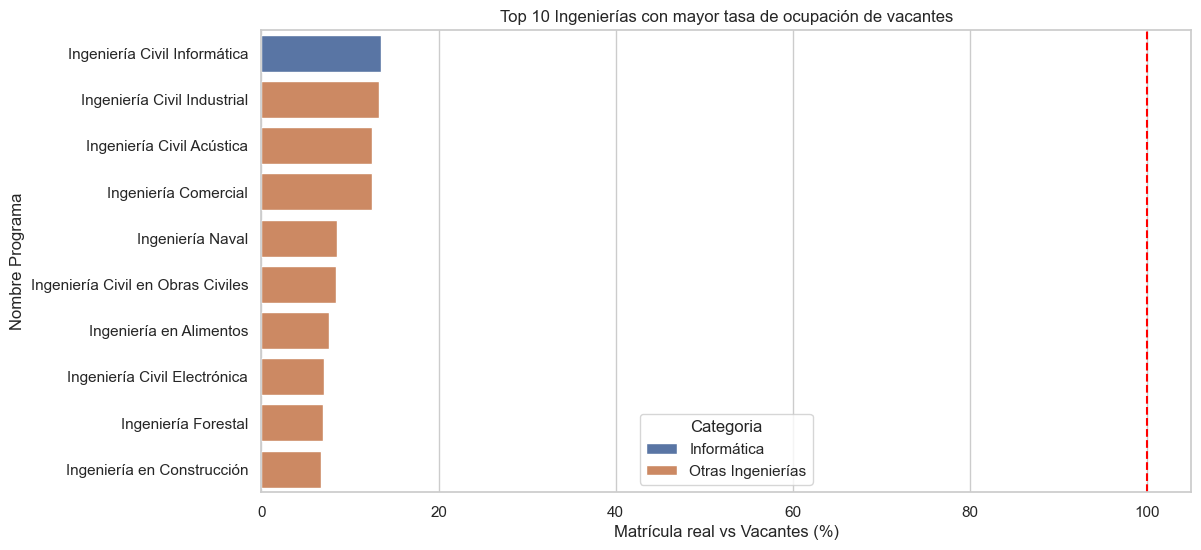

In [15]:
# --- GRÁFICO 3: TASA DE LLENADO (Sobredemanda) ---
plt.figure()
df_ing['Tasa_Llenado'] = (df_ing['Matrícula Primer Año'] / df_ing['Vacantes']) * 100
# Ordenar para ver cuáles están más llenas
df_sorted = df_ing.sort_values('Tasa_Llenado', ascending=False).head(10)

sns.barplot(data=df_sorted, x='Tasa_Llenado', y='Nombre Programa', hue='Categoria')
plt.axvline(100, color='red', linestyle='--') # Línea de capacidad máxima
plt.title('Top 10 Ingenierías con mayor tasa de ocupación de vacantes')
plt.xlabel('Matrícula real vs Vacantes (%)')
plt.show()

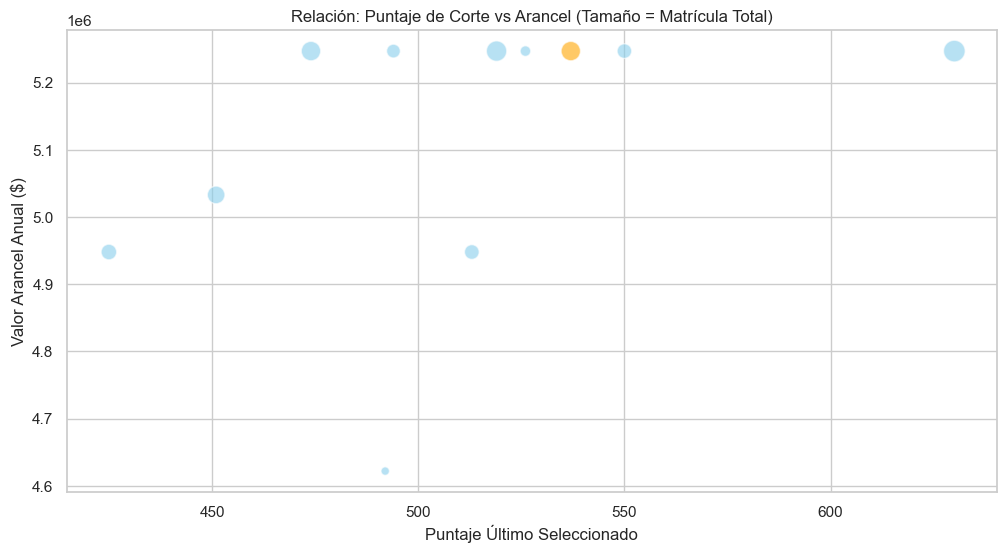

In [16]:
# --- GRÁFICO 4: BUBBLE CHART (Costo vs Corte vs Tamaño) ---
plt.figure()
# Eliminamos filas con datos nulos en estas columnas para que no de error
df_bubble = df_ing.dropna(subset=['Puntaje de corte (último seleccionado)', 'Valor de arancel', 'Matrícula Total'])

scatter = plt.scatter(
    df_bubble['Puntaje de corte (último seleccionado)'], 
    df_bubble['Valor de arancel'],
    s=df_bubble['Matrícula Total'] * 0.5, # Tamaño de la burbuja
    c=df_bubble['Categoria'].map({'Informática': 'orange', 'Otras Ingenierías': 'skyblue'}),
    alpha=0.6,
    edgecolors="w"
)
plt.title('Relación: Puntaje de Corte vs Arancel (Tamaño = Matrícula Total)')
plt.xlabel('Puntaje Último Seleccionado')
plt.ylabel('Valor Arancel Anual ($)')
plt.show()